<a href="https://colab.research.google.com/github/AlisonTDoyle/Machine-Learning-Lego-Brick-Identification/blob/main/Model_2_VGG_All_Layers_Removal_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [25]:
import numpy as np
import pandas as pd
import os

from google.colab import drive
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras import layers
from keras import ops

import tensorflow as tf

# Data read-in and preparation

In [26]:
# mount drive to access lego brick images
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# read in files
SMALL_LEGO_FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/ML - CA2 (Lego Brick)/SmallLego'
NUMBER_OF_BRICK_TYPES = 5

image_data = []

for brick_type in range(NUMBER_OF_BRICK_TYPES):
    subfolder_path = os.path.join(SMALL_LEGO_FOLDER_PATH, str(brick_type))

    # Check if the subfolder exists
    if os.path.exists(subfolder_path):
        # Loop through each image in the subfolder
        for image_name in os.listdir(subfolder_path):
            image_path = os.path.join(subfolder_path, image_name)

            # Open the image and convert it to a numpy array
            img = Image.open(image_path)
            img_array = np.array(img)

            # Append the image data to the list
            # image_data.append({
            #     'brick_type': brick_type,
            #     'image_name': image_name,
            #     'image_path': image_path,
            #     'image_data': img_array
            # })
            image_data.append(img_array)

# Create a DataFrame from the list
# df = pd.DataFrame(image_data)

# Display the DataFrame
# print(df.head())

print(image_data.count)

<built-in method count of list object at 0x7a99cff4da00>


In [28]:
SEED = 505
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    SMALL_LEGO_FOLDER_PATH,
    validation_split=0.4,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

other_ds = keras.utils.image_dataset_from_directory(
    SMALL_LEGO_FOLDER_PATH,
    validation_split=0.4,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# split the remaining 40% evenly into validation and test (20% each)
other_size = other_ds.cardinality().numpy()
half = other_size // 2

validation_ds = other_ds.take(half)
test_ds = other_ds.skip(half)

print(f"Number of training samples: {train_ds.cardinality()}")
print(f"Number of validation samples: {validation_ds.cardinality()}")
print(f"Number of test samples: {test_ds.cardinality()}")

Found 5012 files belonging to 5 classes.
Using 3008 files for training.
Found 5012 files belonging to 5 classes.
Using 2004 files for validation.
Number of training samples: 94
Number of validation samples: 31
Number of test samples: 32


In [29]:
# apply VGG16 preprocessing to all datasets
preprocess = keras.applications.vgg16.preprocess_input

training_data = train_ds.map(lambda x, y: (preprocess(x), y))
validation_data = validation_ds.map(lambda x, y: (preprocess(x), y))
testing_data = test_ds.map(lambda x, y: (preprocess(x), y))

# Model Training and Testing

## Creating Model

In [30]:
# initialise base model
basic_vgg16_model = keras.applications.VGG16(
    weights="imagenet",
    name="vgg16",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [31]:
# creating summary to make sure model was created alright
basic_vgg16_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# create new model using all layers except the last 2
lego_model = keras.Model(
    inputs=basic_vgg16_model.input,
    outputs=basic_vgg16_model.output
)

In [33]:
# create custom layers based on lego images
x = lego_model.output
x = keras.layers.Flatten(name="flatten_lego")(x)
x = keras.layers.Dense(4096, activation="relu", name="fc2_lego")(x)
output = keras.layers.Dense(NUMBER_OF_BRICK_TYPES, activation="softmax", name="predictions_lego")(x)
lego_model = keras.Model(inputs=lego_model.input, outputs=output)

# freeze the older layers so they don't get overwritten
for layer in lego_model.layers[:-3]:
      layer.trainable = False


In [34]:
# check new custom model
lego_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_lego (Flatten)          │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2_lego (Dense)                │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions_lego (Dense)        │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,499,717 (448.23 MB)

 Trainable params: 102,785,029 (392.09 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Training Lego Model

In [35]:
lego_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# training
EPOCHS = 10

lego_model.fit(training_data, epochs=EPOCHS, validation_data=validation_data)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 29s 276ms/step - accuracy: 0.8720 - loss: 46.5660 - val_accuracy: 0.9587 - val_loss: 2.5656
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 297ms/step - accuracy: 0.9561 - loss: 2.7761 - val_accuracy: 0.9173 - val_loss: 6.1486
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 285ms/step - accuracy: 0.9837 - loss: 0.8031 - val_accuracy: 0.9657 - val_loss: 2.1812
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 274ms/step - accuracy: 0.9904 - loss: 0.3949 - val_accuracy: 0.9698 - val_loss: 2.3598
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 291ms/step - accuracy: 0.9953 - loss: 0.1791 - val_accuracy: 0.9647 - val_loss: 2.9122
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 286ms/step - accuracy: 0.9967 - loss: 0.1127 - val_accuracy: 0.9728 - val_loss: 1.8241
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 279ms/step - accuracy: 0.9967 - loss: 0.0916 - val_accuracy: 0.9728 - val_loss: 3.1691
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 283ms/step - accuracy: 0.9983 - loss: 0.0879 - val_acc

In [36]:
print("Test dataset evaluation")
# lego_model.evaluate(testing_data)

Test dataset evaluation


              precision    recall  f1-score   support

     Brick 0       0.98      0.99      0.98       219
     Brick 1       0.98      0.97      0.97       191
     Brick 2       0.99      0.99      0.99       209
     Brick 3       1.00      0.99      1.00       197
     Brick 4       0.97      0.98      0.98       196

    accuracy                           0.99      1012
   macro avg       0.99      0.98      0.99      1012
weighted avg       0.99      0.99      0.99      1012



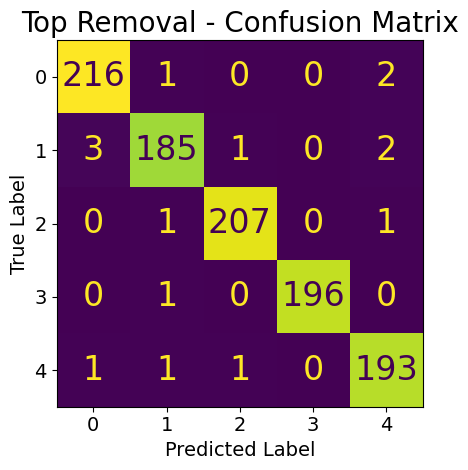

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# collect all true labels and predictions from test set
y_true = []
y_pred = []

for images, labels in testing_data:
    predictions = lego_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

# print a classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=[f'Brick {i}' for i in range(NUMBER_OF_BRICK_TYPES)]
))

# plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm = ConfusionMatrixDisplay(confusion_matrix=cm)
cm.plot(colorbar=False, text_kw={"fontsize": 24})

plt.title('Top Removal - Confusion Matrix',  fontsize=20)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

# Resources used
- [Keras - Transfer Learning and Fine-Tuning](https://keras.io/guides/transfer_learning/)
- [Keras - VGG16 and VGG19 Models](https://keras.io/api/applications/vgg/vgg_models/#vgg16-function)
